In [1]:
import os
import pandas as pd

# Root directory of your dataset
DATA_DIR = "CUB_200_2011"
# Path to the image folder
IMAGE_DIR = os.path.join(DATA_DIR, "images")

####################################
## Step 1: Load Metadata Files
####################################
# images.txt: maps image_id → relative file path
images_df = pd.read_csv(
    os.path.join(DATA_DIR, "images.txt"),
    sep=" ",
    names=["image_id", "image_path"]
)

# image_class_labels.txt: maps image_id → class label
labels_df = pd.read_csv(
    os.path.join(DATA_DIR, "image_class_labels.txt"),
    sep=" ",
    names=["image_id", "class_id"]
)

# bounding_boxes.txt: provides object localisation (bird region)
bbox_df = pd.read_csv(
    os.path.join(DATA_DIR, "bounding_boxes.txt"),
    sep=" ",
    names=["image_id", "x", "y", "width", "height"]
)

# train_test_split.txt: indicates whether image is training or testing
split_df = pd.read_csv(
    os.path.join(DATA_DIR, "train_test_split.txt"),
    sep=" ",
    names=["image_id", "is_train"]
)

####################################
## Step 2: Merge All Information
####################################
data = images_df.merge(labels_df, on="image_id")
data = data.merge(bbox_df, on="image_id")
data = data.merge(split_df, on="image_id")

####################################
## Step 3: Remap class labels to 0–19
####################################
# Get unique class IDs (e.g., [3, 7, 15, ...])
unique_classes = sorted(data["class_id"].unique())

# Create mapping → convert labels to 0–(N-1)
class_mapping = {old: new for new, old in enumerate(unique_classes)}

# Apply mapping
data["label"] = data["class_id"].map(class_mapping)

# Detect how many classes are actually present after remapping
NUM_CLASSES = int(data["label"].nunique())
print("Detected number of classes:", NUM_CLASSES)

####################################
## Step 4: Build Full Image Paths
####################################
data["full_path"] = data["image_path"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

####################################
## Step 5: Split into Training and Testing Sets
####################################
train_df = data[data["is_train"] == 1].reset_index(drop=True)
test_df = data[data["is_train"] == 0].reset_index(drop=True)

train_paths = train_df["full_path"].values
train_labels = train_df["label"].values
train_bboxes = train_df[["x", "y", "width", "height"]].values

test_paths = test_df["full_path"].values
test_labels = test_df["label"].values
test_bboxes = test_df[["x", "y", "width", "height"]].values

print("Number of classes:", data["label"].nunique())

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

Detected number of classes: 200
Number of classes: 200
Training samples: 5994
Testing samples: 5794


## Experiment 1: Whole Image + HOG + SVM (Example Code)


In [ ]:
from skimage.feature import hog
from skimage.color import rgb2gray
from skimage.transform import resize
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from PIL import Image
import numpy as np

# This function extracts HOG feature from an image
def extract_hog(image_path):
    # Load image and convert to RGB
    image = Image.open(image_path).convert("RGB")
    
    # Resize to fixed size for consistent feature extraction
    image = resize(np.array(image), (128, 128))
    
    # Convert to grayscale (HOG works on intensity gradients)
    gray = rgb2gray(image)

    # Extract HOG features (edge/shape descriptors)
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2)
    )
    return features

# This function builds the dataset (X, y)
def build_dataset(paths, labels):
    X, y = [], []
    for p, l in zip(paths, labels):
        # Extract feature for each image
        X.append(extract_hog(p))
        y.append(l)
    return np.array(X), np.array(y)


# Build training and testing feature sets
X_train, y_train = build_dataset(train_paths, train_labels)
X_test, y_test = build_dataset(test_paths, test_labels)

# Train SVM classifier (linear kernel works well for HOG)
model = SVC(kernel="linear")
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate performance
print("Experiment 1 (Whole Image + HOG + SVM) Accuracy:", accuracy_score(y_test, y_pred))

# You should also calculate the confusion matrix and visualise some correct/incorrect samples to reason the results.

## Experiment 2: Whole Image + Deep Learning
### (a) CNN from Scratch (Example Code)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
# NUM_CLASSES is defined from the dataset preprocessing step above
def load_image(path, label):
    # Read image file
    img = tf.io.read_file(path)
    
    # Decode JPEG → tensor
    img = tf.image.decode_jpeg(img, channels=3)
    
    # Resize to CNN input size
    img = tf.image.resize(img, IMG_SIZE)
    
    # Normalize pixel values to [0,1]
    img = img / 255.0
    
    return img, label


# Build TensorFlow dataset
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(load_image).shuffle(500).batch(BATCH_SIZE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(load_image).batch(BATCH_SIZE)


def cnn_scratch():
    # Define simple CNN architecture
    model = models.Sequential([
        layers.Input((224,224,3)),

        # Learn low-level features (edges, textures)
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),

        # Learn more complex patterns
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),

        # Learn higher-level object structures
        layers.Conv2D(128, 3, activation='relu'),
        layers.MaxPooling2D(),

        # Flatten feature maps to vector
        layers.Flatten(),

        # Fully connected layer for classification
        layers.Dense(128, activation='relu'),

        # Output layer for all detected classes
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    # Compile model
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = cnn_scratch()

# Train CNN
model.fit(train_ds, epochs=10)

# Evaluate performance
print("Experiment 2A (Whole Image + CNN from Scratch) Accuracy:", model.evaluate(test_ds)[1])

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 150s 787ms/step - accuracy: 0.0123 - loss: 5.1254
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 145s 771ms/step - accuracy: 0.0217 - loss: 4.6158
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 144s 765ms/step - accuracy: 0.0297 - loss: 4.3232
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 142s 756ms/step - accuracy: 0.0377 - loss: 4.3185
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 142s 753ms/step - accuracy: 0.0409 - loss: 4.3926
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 145s 771ms/step - accuracy: 0.0537 - loss: 4.1090
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 145s 772ms/step - accuracy: 0.0674 - loss: 4.0102
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 145s 770ms/step - accuracy: 0.0801 - loss: 3.9766
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 145s 771ms/step - accuracy: 0.0784 - loss: 4.1102
Epoch 10/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 145s 769ms/step - accuracy: 0.1026 - loss: 3.8681
182/182 ━━━━━━━━━━━━━━━━━━━━ 36s 196ms/step - accuracy: 0.0185 - loss: 7.2947
Experiment 2A (Whole 

## Experiment 2: Whole Image + Deep Learning (Example Code)
### (B) Transfer Learning
In this example, we will use the pre-trained model MobileNetV2 and apply transfer learning to our problem.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def load_image_transfer(path, label):
    # Load and decode image
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    # Resize to model input size
    img = tf.image.resize(img, IMG_SIZE)

    # Apply pretrained model normalization
    img = preprocess_input(img)

    return img, label


# Create dataset
train_ds_t = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds_t = train_ds_t.map(load_image_transfer).batch(BATCH_SIZE)

test_ds_t = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds_t = test_ds_t.map(load_image_transfer).batch(BATCH_SIZE)


def transfer_model():
    # Load pretrained model (feature extractor)
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

    # Freeze pretrained layers (do not update weights)
    base.trainable = False

    # Add custom classification head
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = tf.keras.Model(base.input, out)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = transfer_model()

# Train only classifier head
model.fit(train_ds_t, epochs=10)

print("Experiment 2B (Whole Image + Transfer Learning) Accuracy:", model.evaluate(test_ds_t)[1])

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 97s 499ms/step - accuracy: 0.0000e+00 - loss: 5.4561
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 94s 500ms/step - accuracy: 0.0092 - loss: 5.2669
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 94s 498ms/step - accuracy: 0.0110 - loss: 5.0669
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 94s 502ms/step - accuracy: 0.0405 - loss: 4.8005
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 96s 513ms/step - accuracy: 0.0417 - loss: 4.5678
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 96s 511ms/step - accuracy: 0.0727 - loss: 4.3687
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 96s 511ms/step - accuracy: 0.0759 - loss: 4.1234
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 96s 510ms/step - accuracy: 0.1098 - loss: 3.8262
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 96s 509ms/step - accuracy: 0.1415 - loss: 3.5259
Epoch 10/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 96s 511ms/step - accuracy: 0.1782 - loss: 3.3260
182/182 ━━━━━━━━━━━━━━━━━━━━ 94s 510ms/step - accuracy: 0.0675 - loss: 7.3070
Experiment 2B (Whole Image 

## Experiment 3: Bounding Box + HOG + SVM (Example Code)


In [ ]:
def extract_hog_bbox(path, bbox):
    x, y, w, h = bbox

    # Load image
    img = Image.open(path).convert("RGB")

    # Crop only the object region (bird)
    crop = img.crop((x, y, x+w, y+h))

    # Resize for consistency
    crop = resize(np.array(crop), (128,128))

    # Convert to grayscale
    gray = rgb2gray(crop)

    # Extract HOG features from cropped region
    return hog(gray, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2))


def build_bbox_dataset(paths, labels, bboxes):
    X, y = [], []
    for p, l, b in zip(paths, labels, bboxes):
        X.append(extract_hog_bbox(p, b))
        y.append(l)
    return np.array(X), np.array(y)


# Build dataset using cropped images
X_train, y_train = build_bbox_dataset(train_paths, train_labels, train_bboxes)
X_test, y_test = build_bbox_dataset(test_paths, test_labels, test_bboxes)

# Train SVM
model = SVC(kernel="linear")
model.fit(X_train, y_train)

# Evaluate
print("Experiment 3 (Bounding Box + HOG + SVM) Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Experiment 3 (Bounding Box + HOG + SVM) Accuracy: 0.09924059371763894


## Experiment 4: Bounding Box + Deep Learning (Example Code)
### (A) CNN from Scratch


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_bbox(path, label, bbox):
    # Load image
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    # Get image height and width
    img_shape = tf.shape(img)
    img_h = img_shape[0]
    img_w = img_shape[1]

    # Read bbox values
    x = tf.cast(bbox[0], tf.int32)
    y = tf.cast(bbox[1], tf.int32)
    w = tf.cast(bbox[2], tf.int32)
    h = tf.cast(bbox[3], tf.int32)

    # Make sure x and y are not negative
    x = tf.maximum(x, 0)
    y = tf.maximum(y, 0)

    # Make sure width and height do not exceed image boundary
    w = tf.minimum(w, img_w - x)
    h = tf.minimum(h, img_h - y)

    # Make sure width and height are at least 1
    w = tf.maximum(w, 1)
    h = tf.maximum(h, 1)

    # Crop bird region
    img = tf.image.crop_to_bounding_box(
        img,
        offset_height=y,
        offset_width=x,
        target_height=h,
        target_width=w
    )

    # Resize and normalise
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0

    return img, label


# Build dataset with cropped images
train_ds_bbox = tf.data.Dataset.from_tensor_slices((train_paths, train_labels, train_bboxes))
train_ds_bbox = (
    train_ds_bbox
    .map(load_bbox)
    .shuffle(500)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


# Build dataset with cropped images
test_ds_bbox = tf.data.Dataset.from_tensor_slices((test_paths, test_labels, test_bboxes))
test_ds_bbox = (
    test_ds_bbox
    .map(load_bbox)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

model = cnn_scratch()

# Train CNN on cropped images
model.fit(train_ds_bbox, epochs=10)

print("Experiment 4A (Bounding Box + CNN from Scratch) Accuracy:", model.evaluate(test_ds_bbox)[1])


Epoch 1/10
  3/188 ━━━━━━━━━━━━━━━━━━━━ 2:23 774ms/step - accuracy: 0.0920 - loss: 4.6576

2026-05-12 17:43:17.759353: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at sparse_xent_op.cc:102 : INVALID_ARGUMENT: Received a label value of 20 which is outside the valid range of [0, 20).  Label values: 0 0 9 17 18 12 18 11 0 4 15 9 1 17 14 13 7 4 13 1 15 13 6 16 5 17 6 2 3 4 20 6
2026-05-12 17:43:17.759403: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INVALID_ARGUMENT: Received a label value of 20 which is outside the valid range of [0, 20).  Label values: 0 0 9 17 18 12 18 11 0 4 15 9 1 17 14 13 7 4 13 1 15 13 6 16 5 17 6 2 3 4 20 6
	 [[{{function_node __inference_one_step_on_data_37504}}{{node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits}}]]


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/systems/miniconda3/envs/CVIA/lib/python3.13/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/systems/miniconda3/envs/CVIA/lib/python3.13/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/systems/miniconda3/envs/CVIA/lib/python3.13/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/home/systems/miniconda3/envs/CVIA/lib/python3.13/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/systems/miniconda3/envs/CVIA/lib/python3.13/asyncio/base_events.py", line 677, in run_forever

  File "/home/systems/miniconda3/envs/CVIA/lib/python3.13/asyncio/base_eve

## Experiment 4: Bounding Box + Deep Learning (Example Code)
### (B) Transfer Learning

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def load_bbox_transfer(path, label, bbox):
    # First crop + normalize like before
    img, label = load_bbox(path, label, bbox)

    # Convert to pretrained model input format
    img = preprocess_input(img * 255.0)

    return img, label

def transfer_model():
    # Load pretrained model (feature extractor)
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

    # Freeze pretrained layers (do not update weights)
    base.trainable = False

    # Add custom classification head
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = tf.keras.Model(base.input, out)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


train_ds_bbox_t = tf.data.Dataset.from_tensor_slices((train_paths, train_labels, train_bboxes))
train_ds_bbox_t = train_ds_bbox_t.map(lambda p,l,b: load_bbox_transfer(p,l,b)).batch(BATCH_SIZE)

test_ds_bbox_t = tf.data.Dataset.from_tensor_slices((test_paths, test_labels, test_bboxes))
test_ds_bbox_t = test_ds_bbox_t.map(lambda p,l,b: load_bbox_transfer(p,l,b)).batch(BATCH_SIZE)


model = transfer_model()

# Train transfer learning model on cropped images
model.fit(train_ds_bbox_t, epochs=10)

print("Experiment 4B (Bounding Box + Transfer Learning) Accuracy:", model.evaluate(test_ds_bbox_t)[1])

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 447ms/step - accuracy: 0.0202 - loss: 4.0995
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 428ms/step - accuracy: 0.1513 - loss: 2.8317
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 439ms/step - accuracy: 0.2892 - loss: 2.4942
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 432ms/step - accuracy: 0.4484 - loss: 1.9000
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 427ms/step - accuracy: 0.6614 - loss: 1.3672
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 424ms/step - accuracy: 0.7489 - loss: 1.0433
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 443ms/step - accuracy: 0.8352 - loss: 0.7555
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 444ms/step - accuracy: 0.8744 - loss: 0.5853
Epoch 9/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 465ms/step - accuracy: 0.9047 - loss: 0.4654
Epoch 10/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 459ms/step - accuracy: 0.9170 - loss: 0.3999
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 465ms/step - accuracy: 0.8610 - loss: 0.5343
Experiment 4B (Bounding Box + Transfer Learning) Accurac

## Adding Data Augmentation and Cross Validation
Finally, let's look at data augmentation and k-fold cross validation. I will use the Experiment 4B as an example.

Data augmentation artificially increases the diversity of the training data by applying small transformations to images. Instead of collecting more data, we create new variations of existing images. In the example code, we:
- randomly flip the image left to right
- rotates image by a small angle (+-10%)
- randomly zooms in/our slightly

This helps the model generalise better to unseen data, reduces overfitting (model memorising training images), makes the model more robust to real-world variations such as:
- different viewpoints
- slight rotations
- scale changes

It is important to note: data augmentation is applied only during training, not during validation or testing.
- Validation and test results should reflect true model performance
- No artificial transformations should affect evaluation

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
K = 5 # K fold cross validation

################################
## Data augmentation
################################
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),  # flip
    layers.RandomRotation(0.1),  # rotate
    layers.RandomZoom(0.1),  # zoom in/out
])


################################
## Safe Bounding Box Loader for Transfer Learning (this part remains the same)
################################
def load_bbox_transfer(path, label, bbox):
    # Read image file
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    # Get image size
    img_shape = tf.shape(img)
    img_h = img_shape[0]
    img_w = img_shape[1]

    # Read bounding box values
    x = tf.cast(bbox[0], tf.int32)
    y = tf.cast(bbox[1], tf.int32)
    w = tf.cast(bbox[2], tf.int32)
    h = tf.cast(bbox[3], tf.int32)

    # Clip bounding box to valid image boundary
    x = tf.maximum(x, 0)
    y = tf.maximum(y, 0)

    w = tf.minimum(w, img_w - x)
    h = tf.minimum(h, img_h - y)

    w = tf.maximum(w, 1)
    h = tf.maximum(h, 1)

    # Crop bird region
    img = tf.image.crop_to_bounding_box(
        img,
        offset_height=y,
        offset_width=x,
        target_height=h,
        target_width=w
    )

    # Resize to MobileNetV2 input size
    img = tf.image.resize(img, IMG_SIZE)

    # Apply MobileNetV2 preprocessing
    img = preprocess_input(img)

    return img, label


################################
## Transfer Learning Model with Augmentation
################################
def create_transfer_model_with_augmentation():
    # Load pretrained MobileNetV2 without the original classifier
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze pretrained layers
    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))

    # Apply data augmentation only during training
    x = data_augmentation(inputs)

    # Extract pretrained visual features
    x = base_model(x, training=False)

    # Convert feature maps into a feature vector
    x = layers.GlobalAveragePooling2D()(x)

    # Classification head
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model



################################
## K-Fold Cross-Validation
################################

# Convert to NumPy arrays
all_paths = np.array(train_paths)
all_labels = np.array(train_labels)
all_bboxes = np.array(train_bboxes)

# StratifiedKFold is a variation of K-fold cross-validation that ensures each fold
# has a similar class distribution as the original dataset.
skf = StratifiedKFold(
    n_splits=K,
    shuffle=True,
    random_state=42
)

fold_accuracies = []

# loop over the k folds
for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels)):
    print(f"\n===== Fold {fold + 1}/{K} =====")

    # Split data for current fold
    fold_train_paths = all_paths[train_idx]
    fold_train_labels = all_labels[train_idx]
    fold_train_bboxes = all_bboxes[train_idx]

    fold_val_paths = all_paths[val_idx]
    fold_val_labels = all_labels[val_idx]
    fold_val_bboxes = all_bboxes[val_idx]

    # Training dataset
    train_ds = tf.data.Dataset.from_tensor_slices(
        (fold_train_paths, fold_train_labels, fold_train_bboxes)
    )

    train_ds = (
        train_ds
        .map(load_bbox_transfer)
        .shuffle(500)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    # Validation dataset
    val_ds = tf.data.Dataset.from_tensor_slices(
        (fold_val_paths, fold_val_labels, fold_val_bboxes)
    )

    val_ds = (
        val_ds
        .map(load_bbox_transfer)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    # Important: create a new model for each fold
    model = create_transfer_model_with_augmentation()

    # Train model on this fold
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS
    )

    # Evaluate validation performance
    val_loss, val_acc = model.evaluate(val_ds)

    print(f"Fold {fold + 1} Validation Accuracy: {val_acc:.4f}")

    fold_accuracies.append(val_acc)

print("\nExperiment 4B Cross-validation results")
print("Fold accuracies:", fold_accuracies)
print("Mean validation accuracy:", np.mean(fold_accuracies))
print("Standard deviation:", np.std(fold_accuracies))


===== Fold 1/5 =====
Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 644ms/step - accuracy: 0.1921 - loss: 2.7649 - val_accuracy: 0.5419 - val_loss: 1.9268
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 603ms/step - accuracy: 0.4558 - loss: 1.8217 - val_accuracy: 0.7207 - val_loss: 1.2367
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 596ms/step - accuracy: 0.6087 - loss: 1.3155 - val_accuracy: 0.8045 - val_loss: 0.8261
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 594ms/step - accuracy: 0.7125 - loss: 1.0542 - val_accuracy: 0.8380 - val_loss: 0.6610
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 582ms/step - accuracy: 0.7574 - loss: 0.8361 - val_accuracy: 0.8268 - val_loss: 0.5723
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 597ms/step - accuracy: 0.7644 - loss: 0.7550 - val_accuracy: 0.8659 - val_loss: 0.5081
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 602ms/step - accuracy: 0.7952 - loss: 0.6649 - val_accuracy: 0.8939 - val_loss: 0.4601
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 581ms/step - accuracy: 0.8317 - l

## Final Notes: 
In this above example, we did not explicitly distinguish between a validation set and a testing set. However, it is important to clarify that, in best practice, these two sets serve different purposes. A validation set is used during model development to monitor performance and guide decisions such as hyperparameter tuning, while a testing set should remain completely unseen until the very end to provide an unbiased evaluation of the final model. Using the same data for both roles can lead to overly optimistic results, as the model may be indirectly tuned to perform well on that data. Therefore, in more rigorous experimental settings, the dataset should be divided into three parts: training, validation, and testing, to ensure fair and reliable performance assessment.
- Training set → train the model
- Validation set → monitor performance during training and guide hyperparameter tuning
- Testing set → final testing after training

You can think about how to change the above code to have a more rigurous performance assessment.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


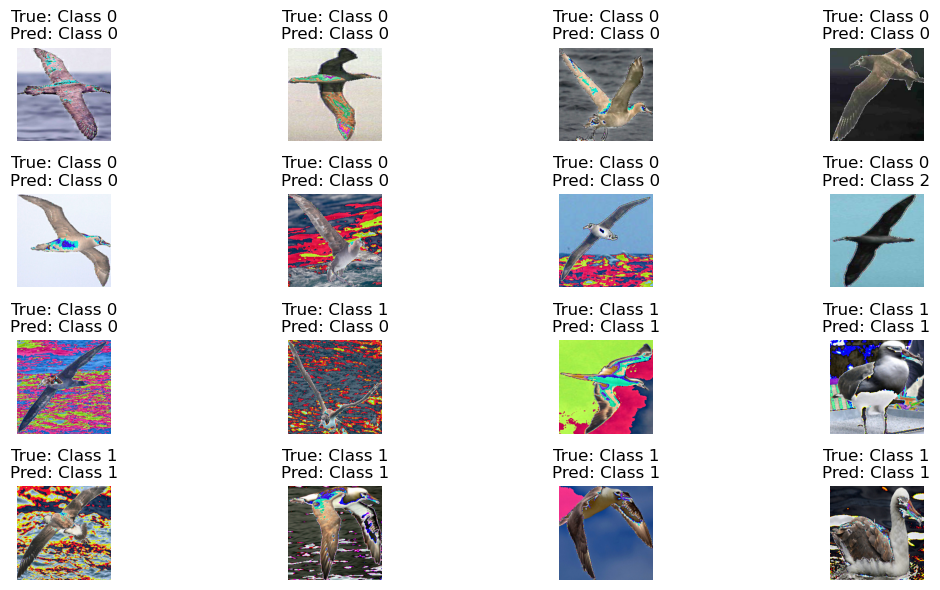

2026-04-30 11:42:05.568775: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
